In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import pymannkendall as mk

In [2]:
df = pd.read_csv("Karnal.csv")

In [3]:
df["TIME"]=pd.to_datetime(df["TIME"])

In [4]:
df=df[df["TIME"].dt.year>1987]

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13880 entries, 4748 to 18627
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   TIME    13880 non-null  datetime64[us]
 1   MAX     13880 non-null  float64       
 2   MIN     13880 non-null  float64       
 3   RF      13880 non-null  float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 433.9 KB


In [6]:
df_Years=np.sort(np.array(df["TIME"].dt.year.value_counts().index))

In [7]:
winter=df[(df["TIME"].dt.month>=1) & (df["TIME"].dt.month<=2) ]
premon=df[(df["TIME"].dt.month>=3) & (df["TIME"].dt.month<=5) ]
mons=df[(df["TIME"].dt.month>=6) & (df["TIME"].dt.month<=9) ]
postmon=df[(df["TIME"].dt.month>=10) & (df["TIME"].dt.month<=12)]

<h1> Datasets
</h1>

In [8]:
monthly_rainfall=[["",1,2,3,4,5,6,7,8,9,10,11,12]]
for i in df_Years:
    monthly_rainfall.append([i]+list(df.groupby(df[df["TIME"].dt.year==i]["TIME"].dt.month)["RF"].sum().reset_index()["RF"].values))
monthly_rainfall=pd.DataFrame(monthly_rainfall)

In [9]:
monthly_maxtemp=[["",1,2,3,4,5,6,7,8,9,10,11,12]]
for i in df_Years:
    monthly_maxtemp.append([i]+list(df.groupby(df[df["TIME"].dt.year==i]["TIME"].dt.month)["MAX"].mean().reset_index()["MAX"].values))
monthly_maxtemp=pd.DataFrame(monthly_maxtemp)

In [10]:
monthly_mintemp=[["",1,2,3,4,5,6,7,8,9,10,11,12]]
for i in df_Years:
    monthly_mintemp.append([i]+list(df.groupby(df[df["TIME"].dt.year==i]["TIME"].dt.month)["MIN"].mean().reset_index()["MIN"].values))
monthly_mintemp=pd.DataFrame(monthly_mintemp)

In [11]:
annual_rainfall=df.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()

In [12]:
annual_maxtemp=df.groupby(df["TIME"].dt.year)["MAX"].mean().reset_index()

In [13]:
annual_mintemp=df.groupby(df["TIME"].dt.year)["MIN"].mean().reset_index()

<h1>Extreme Events</h1'/
                               >


In [14]:
dfEXTREMERIAN=df[(df["RF"]>=64.5)]

In [15]:
dfExtMonthly=pd.DataFrame(np.zeros([df_Years.shape[0],12]),columns=np.arange(1,13))
dfExtMonthly.index=df_Years
for i in np.array(dfEXTREMERIAN["TIME"].dt.year.value_counts().index) :
    for j in np.array(dfEXTREMERIAN[dfEXTREMERIAN["TIME"].dt.year==i]["TIME"].dt.month.value_counts().index):
        dfExtMonthly.loc[i,j]=dfEXTREMERIAN[(dfEXTREMERIAN["TIME"].dt.year==i) & (dfEXTREMERIAN["TIME"].dt.month==j)].shape[0]

In [16]:
dfExtYearly=pd.DataFrame(dfExtMonthly.T.sum(),columns=["freq"])

In [17]:
dfExtMonthSum=pd.DataFrame(dfExtMonthly.sum(),columns=["freq"])

In [18]:
dfExtWinter=pd.DataFrame(dfExtMonthly.T.loc[1:2].sum(),columns=["freq"])
dfExtPremon=pd.DataFrame(dfExtMonthly.T.loc[3:5].sum(),columns=["freq"])
dfExtMon=pd.DataFrame(dfExtMonthly.T.loc[6:9].sum(),columns=["freq"])
dfExtPostmon=pd.DataFrame(dfExtMonthly.T.loc[10:12].sum(),columns=["freq"])

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.04734478579354762), z=np.float64(1.9832027595048534), Tau=np.float64(0.21337126600284495), s=np.float64(150.0), var_s=np.float64(5644.666666666667), slope=np.float64(0.0), intercept=np.float64(1.0))
MEAN:  1.1842105263157894
SD:  1.4677665172211114
CV:  123.94472812089386


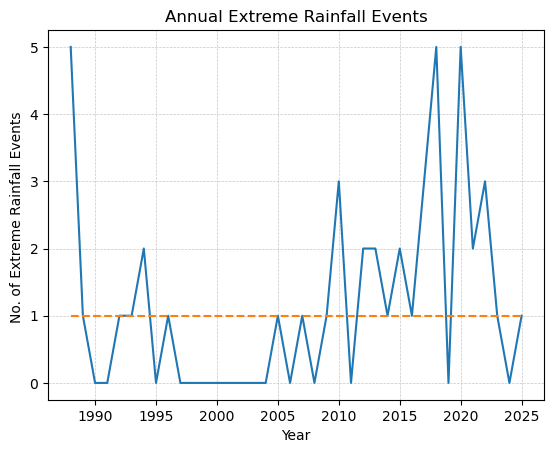

In [19]:
b=dfExtYearly
plt.plot(b.index,b["freq"])
test=mk.original_test(b["freq"])
print(test)
print("MEAN: ",b["freq"].mean())
print("SD: ",b["freq"].std())
print("CV: ",b["freq"].std()/b["freq"].mean()*100)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Annual Extreme Rainfall Events")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(1.0), z=np.float64(0.0), Tau=np.float64(0.001422475106685633), s=np.float64(1.0), var_s=np.float64(481.0), slope=np.float64(0.0), intercept=np.float64(0.0))
MEAN:  0.02631578947368421
SD:  0.16222142113076257
CV:  616.4414002968978


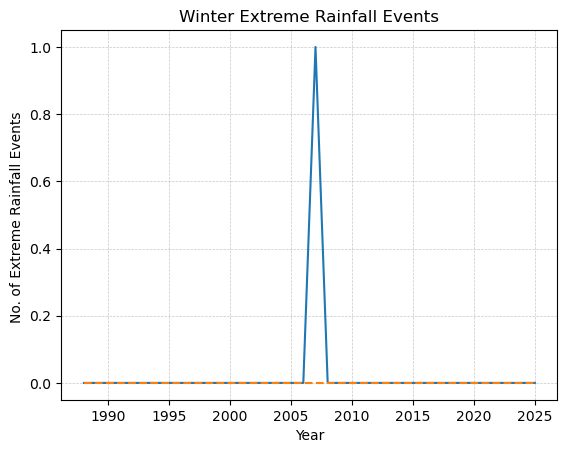

In [20]:
b=dfExtWinter
plt.plot(b.index,b["freq"])
test=mk.original_test(b["freq"])
print(test)
print("MEAN: ",b["freq"].mean())
print("SD: ",b["freq"].std())
print("CV: ",b["freq"].std()/b["freq"].mean()*100)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Winter Extreme Rainfall Events")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.08320962868743176), z=np.float64(1.7323591937206255), Tau=np.float64(0.07681365576102418), s=np.float64(54.0), var_s=np.float64(936.0), slope=np.float64(0.0), intercept=np.float64(0.0))
MEAN:  0.05263157894736842
SD:  0.22629428592141426
CV:  429.95914325068713


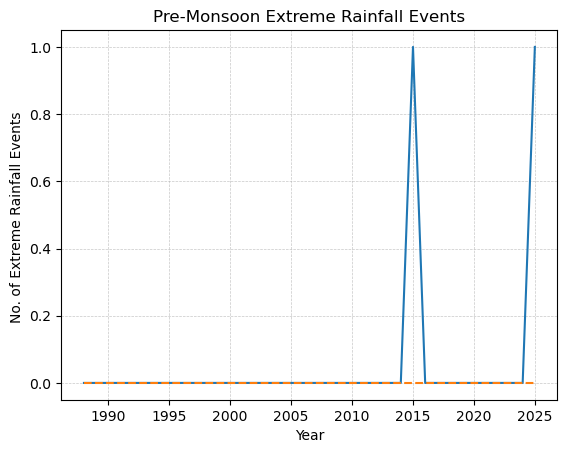

In [21]:
b=dfExtPremon
plt.plot(b.index,b["freq"])
test=mk.original_test(b["freq"])
print(test)
print("MEAN: ",b["freq"].mean())
print("SD: ",b["freq"].std())
print("CV: ",b["freq"].std()/b["freq"].mean()*100)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Pre-Monsoon Extreme Rainfall Events")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.14491493458518967), z=np.float64(1.4577301626781398), Tau=np.float64(0.155049786628734), s=np.float64(109.0), var_s=np.float64(5489.0), slope=np.float64(0.0), intercept=np.float64(1.0))
MEAN:  1.105263157894737
SD:  1.4848691576575799
CV:  134.3453047404477


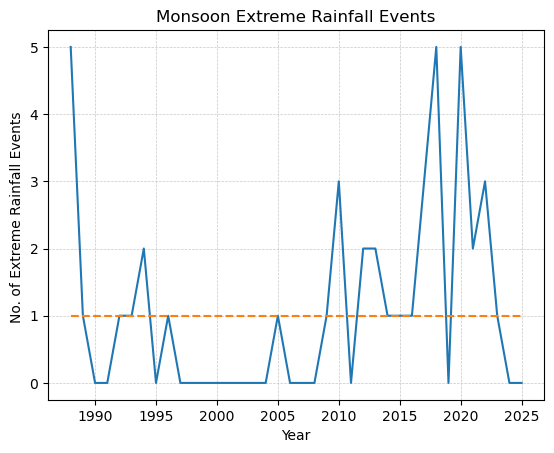

In [22]:
b=dfExtMon
plt.plot(b.index,b["freq"])
test=mk.original_test(b["freq"])
print(test)
print("MEAN: ",b["freq"].mean())
print("SD: ",b["freq"].std())
print("CV: ",b["freq"].std()/b["freq"].mean()*100)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Monsoon Extreme Rainfall Events")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(1.0), z=0, Tau=np.float64(0.0), s=np.float64(0.0), var_s=np.float64(0.0), slope=np.float64(0.0), intercept=np.float64(0.0))


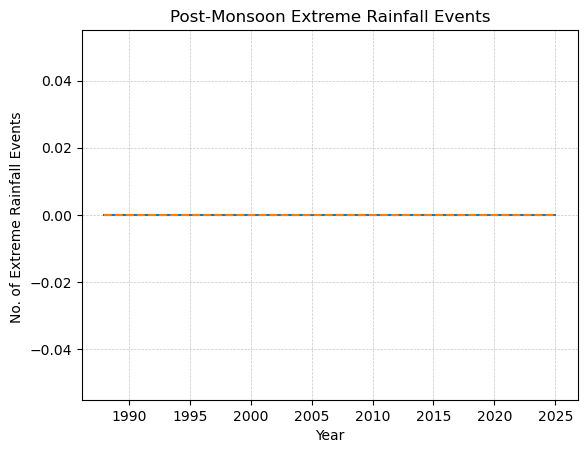

In [23]:
b=dfExtPostmon
plt.plot(b.index,b["freq"])
test=mk.original_test(b["freq"])
print(test)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Post-Monsoon Extreme Rainfall Events")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(1.0), z=np.float64(0.0), Tau=np.float64(0.015151515151515152), s=np.float64(1.0), var_s=np.float64(192.33333333333334), slope=np.float64(0.0), intercept=np.float64(1.0))
MEAN:  3.75
SD:  5.8794712192663905
CV:  156.78589918043707


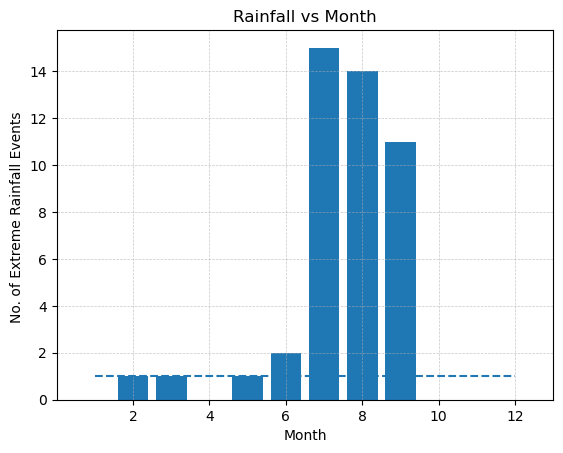

In [24]:
b=dfExtMonthSum
plt.bar(b.index,b["freq"])
test=mk.original_test(b["freq"])
print(test)
print("MEAN: ",b["freq"].mean())
print("SD: ",b["freq"].std())
print("CV: ",b["freq"].std()/b["freq"].mean()*100)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Month")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Rainfall vs Month")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

In [25]:
winterE=winter[(winter["RF"]>=64.5)]
premonE=premon[(premon["RF"]>=64.5)]
monsE=mons[(mons["RF"]>=64.5)]
postmonE=postmon[(postmon["RF"]>=64.5)]

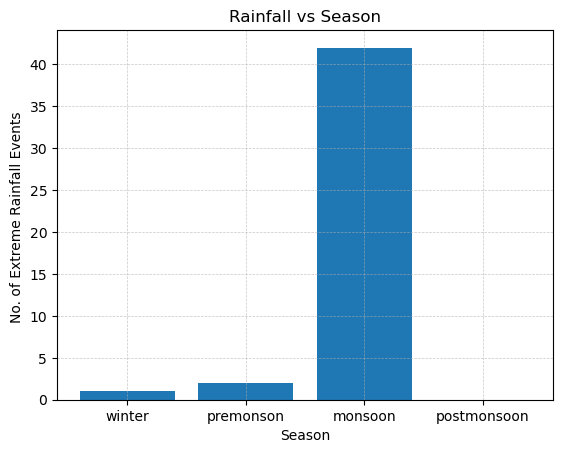

In [26]:
plt.bar(["winter","premonson","monsoon","postmonsoon"],[winterE.shape[0],premonE.shape[0],monsE.shape[0],postmonE.shape[0]])
plt.xlabel("Season")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Rainfall vs Season")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

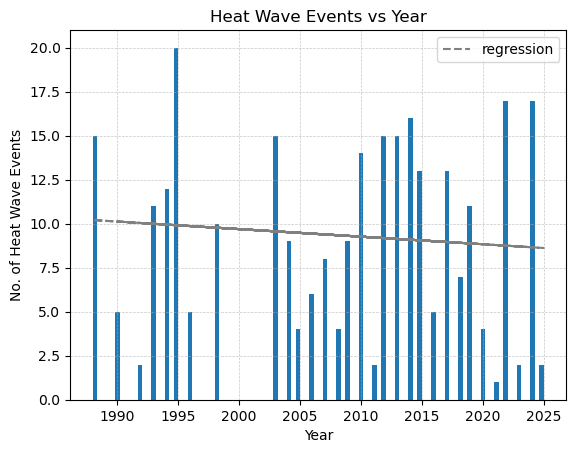

In [27]:
model=LinearRegression()
model.fit(np.array(df[df["MAX"]>=42]["TIME"].dt.year.value_counts().index).reshape(-1,1),df[df["MAX"]>=42]["TIME"].dt.year.value_counts().values)
plt.hist(df[df["MAX"]>=42]["TIME"].dt.year,bins=100)
plt.plot(df[df["MAX"]>=42]["TIME"].dt.year.value_counts().index,model.predict(np.array(df[df["MAX"]>=42]["TIME"].dt.year.value_counts().index).reshape(-1,1)),linestyle="--",c="grey",label="regression")
plt.xlabel("Year")
plt.ylabel("No. of Heat Wave Events")
plt.title("Heat Wave Events vs Year")
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

<h1>Minimum temperature curve</h1>

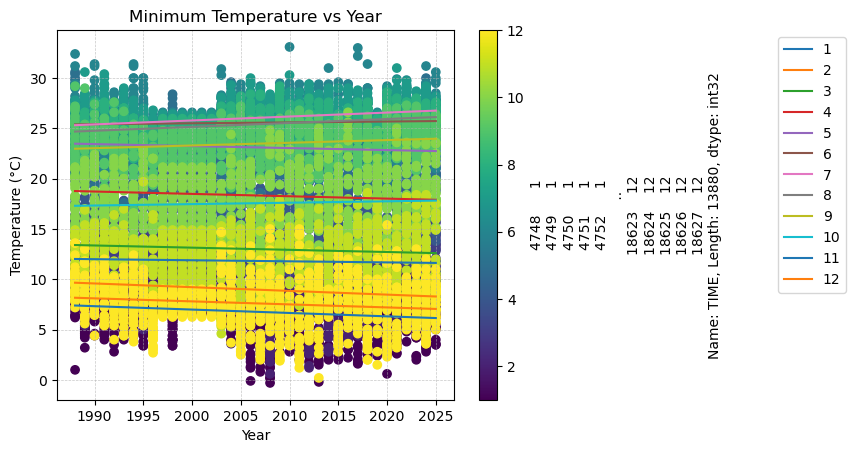

In [28]:
plt.colorbar(plt.scatter(df["TIME"].dt.year,df["MIN"],c=df["TIME"].dt.month), label=df["TIME"].dt.month)
model = LinearRegression()
dff = df.dropna(subset=['MIN'])
for i in range(12):
    temp=dff[dff["TIME"].dt.month==(i+1)]
    model.fit(temp["TIME"].dt.year.values.reshape(-1, 1), temp["MIN"])
    y_pred = model.predict(temp["TIME"].dt.year.values.reshape(-1, 1))
    plt.plot(temp["TIME"].dt.year, y_pred, label=str(i+1))
plt.legend(loc='upper left', bbox_to_anchor=(1.8, 1))
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Minimum Temperature vs Year")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Slope :  [-0.00383313]


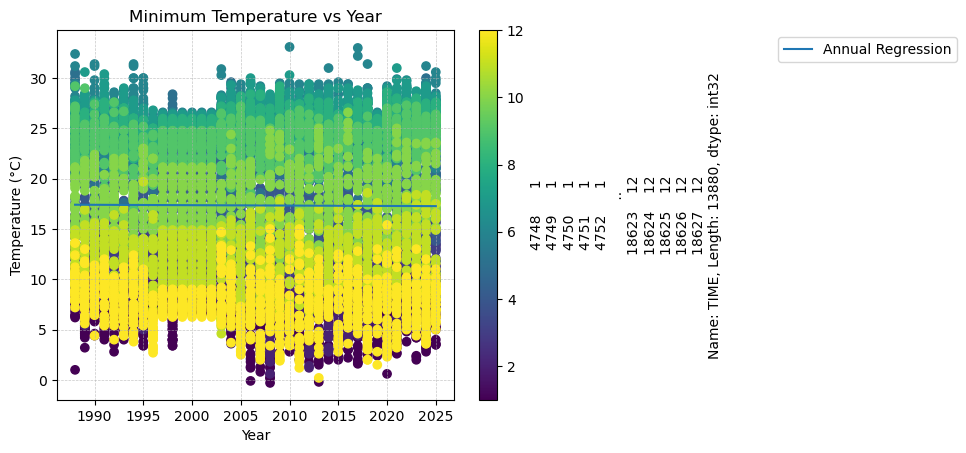

In [29]:
plt.colorbar(plt.scatter(df["TIME"].dt.year,df["MIN"],c=df["TIME"].dt.month), label=df["TIME"].dt.month)
model = LinearRegression()
dff = df.dropna(subset=['MIN'])
model.fit(dff["TIME"].dt.year.values.reshape(-1, 1), dff["MIN"])
y_pred = model.predict(dff["TIME"].dt.year.values.reshape(-1, 1))
plt.plot(dff["TIME"].dt.year, y_pred, label="Annual Regression")
plt.legend(loc='upper left', bbox_to_anchor=(1.8, 1))
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Minimum Temperature vs Year")
print("Slope : ",model.coef_)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

<h5>
    annual minimum temperature is observed to be decreasing atrate of around 0.002 C per year
</h5>

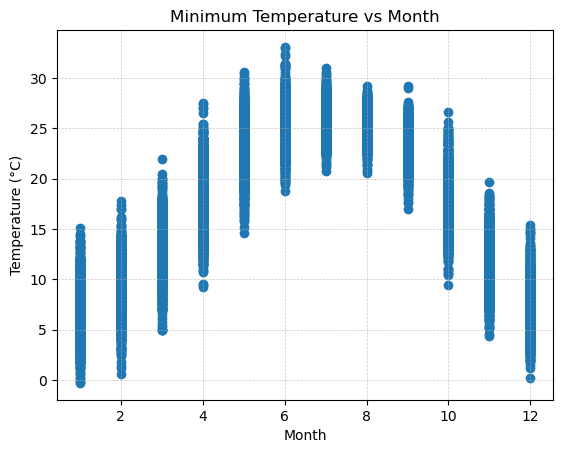

In [30]:
plt.scatter(df["TIME"].dt.month,df["MIN"])
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Minimum Temperature vs Month")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.6326075616104339), z=np.float64(-0.4780599146379515), Tau=np.float64(-0.05547652916073969), s=np.float64(-39.0), var_s=np.float64(6318.333333333333), slope=np.float64(-0.0042584967792774694), intercept=np.float64(17.471725049976573))
MEAN:  17.343587429960248
SD:  0.3821554767066477
CV:  2.203439618532967


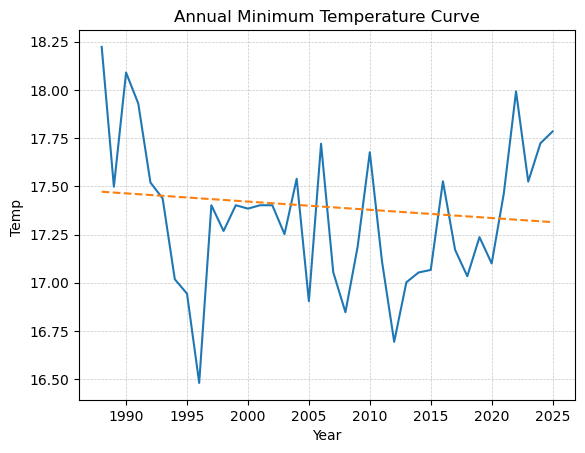

In [31]:
b=annual_mintemp
plt.plot(b["TIME"],b["MIN"])
test=mk.original_test(b["MIN"])
print(test)
print("MEAN: ",b["MIN"].mean())
print("SD: ",b["MIN"].std())
print("CV: ",b["MIN"].std()/b["MIN"].mean()*100)
plt.plot(b["TIME"],test.slope*(b["TIME"]-b["TIME"].min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("Temp ")
plt.title("Annual Minimum Temperature Curve")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

In [32]:
print("Highest Minimum Temp. : ",dff["MIN"].max())
print("Lowest Minimum Temp. : ",dff["MIN"].min())

Highest Minimum Temp. :  33.1
Lowest Minimum Temp. :  -0.3


<h1>Maximum temperature curve  </h1>

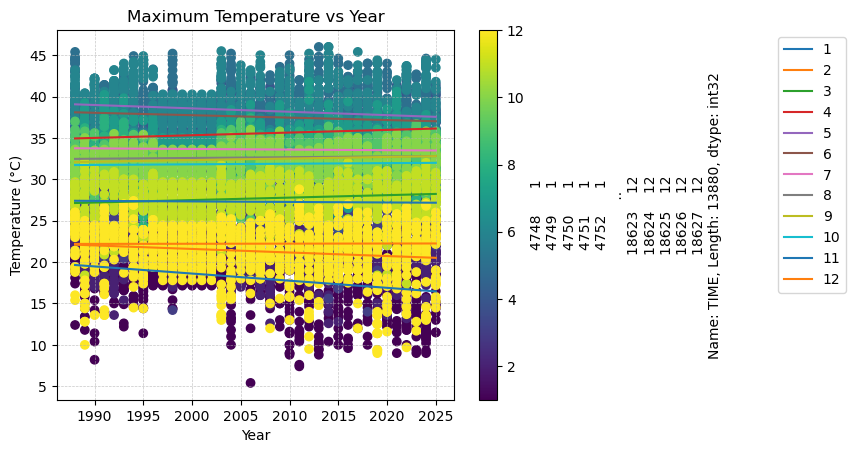

In [33]:
plt.colorbar(plt.scatter(df["TIME"].dt.year,df["MAX"],c=df["TIME"].dt.month), label=df["TIME"].dt.month)
model = LinearRegression()
dff = dff.dropna(subset=['MAX'])
for i in range(12):
    temp=dff[dff["TIME"].dt.month==(i+1)]
    model.fit(temp["TIME"].dt.year.values.reshape(-1, 1), temp["MAX"])
    y_pred = model.predict(temp["TIME"].dt.year.values.reshape(-1, 1))
    plt.plot(temp["TIME"].dt.year, y_pred, label=str(i+1))
plt.legend(loc='upper left', bbox_to_anchor=(1.8, 1))
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Maximum Temperature vs Year")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Slope:  [-0.00968345]


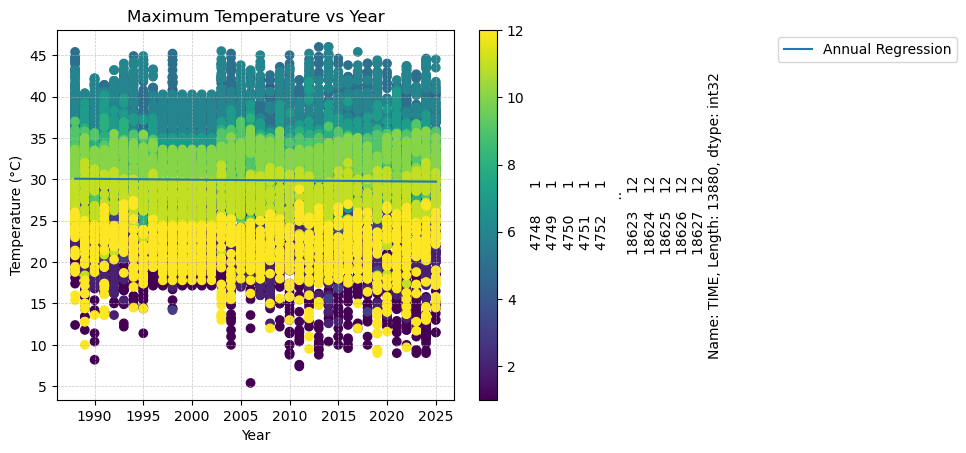

In [34]:
plt.colorbar(plt.scatter(df["TIME"].dt.year,df["MAX"],c=df["TIME"].dt.month), label=df["TIME"].dt.month)
model = LinearRegression()
dff = df.dropna(subset=['MAX'])
model.fit(dff["TIME"].dt.year.values.reshape(-1, 1), dff["MAX"])
y_pred = model.predict(dff["TIME"].dt.year.values.reshape(-1, 1))
plt.plot(dff["TIME"].dt.year, y_pred, label="Annual Regression")
plt.legend(loc='upper left', bbox_to_anchor=(1.8, 1))
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Maximum Temperature vs Year")
print("Slope: ",model.coef_)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

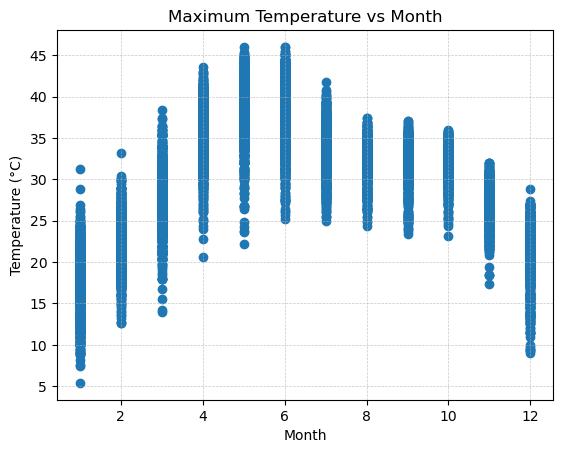

In [35]:
plt.scatter(df["TIME"].dt.month,df["MAX"])
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Maximum Temperature vs Month")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.19074631626767902), z=np.float64(-1.3083745032196568), Tau=np.float64(-0.14935988620199148), s=np.float64(-105.0), var_s=np.float64(6318.333333333333), slope=np.float64(-0.0064715429526365715), intercept=np.float64(30.071526569861152))
MEAN:  29.899633114178055
SD:  0.3609700378359415
CV:  1.2072724653760845


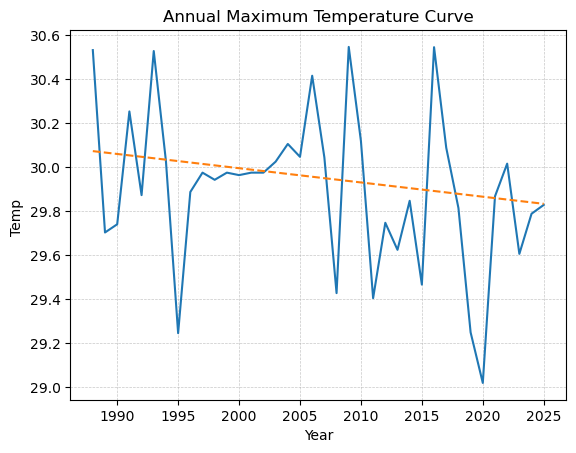

In [36]:
b=annual_maxtemp
plt.plot(b["TIME"],b["MAX"])
test=mk.original_test(b["MAX"])
print(test)
print("MEAN: ",b["MAX"].mean())
print("SD: ",b["MAX"].std())
print("CV: ",b["MAX"].std()/b["MAX"].mean()*100)
plt.plot(b["TIME"],test.slope*(b["TIME"]-b["TIME"].min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("Temp ")
plt.title("Annual Maximum Temperature Curve")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

In [37]:
print("Highest Maximum Temp. : ",dff["MAX"].max())
print("Lowest Maximum Temp. : ",dff["MAX"].min())

Highest Maximum Temp. :  46.0
Lowest Maximum Temp. :  5.4


<h1>Rainfall curve </h1>

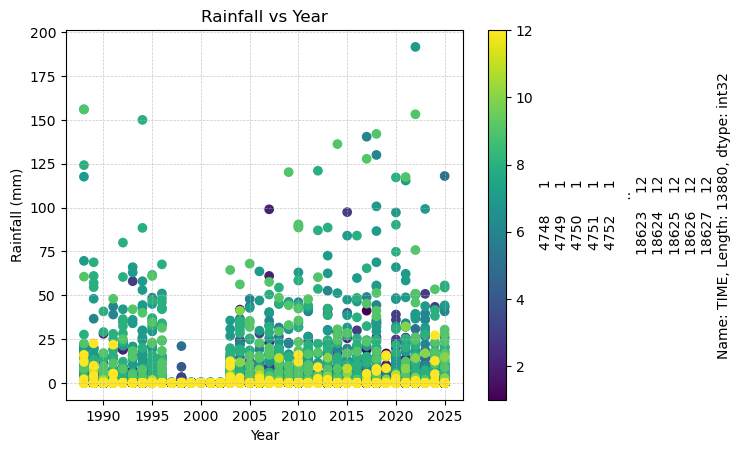

In [38]:
plt.colorbar(plt.scatter(df["TIME"].dt.year,df["RF"],c=df["TIME"].dt.month), label=df["TIME"].dt.month)
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Rainfall vs Year")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

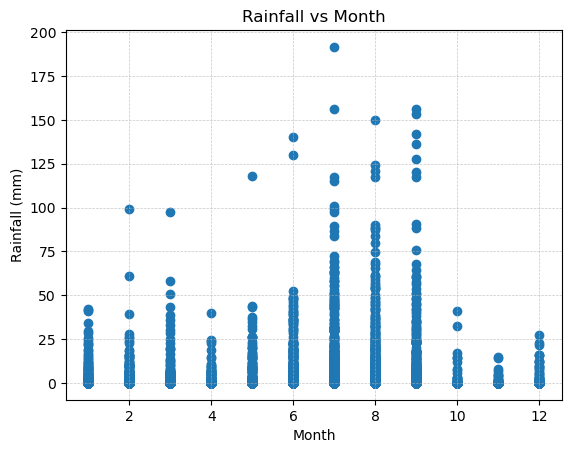

In [39]:
plt.scatter(df["TIME"].dt.month,df["RF"])
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.title("Rainfall vs Month")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

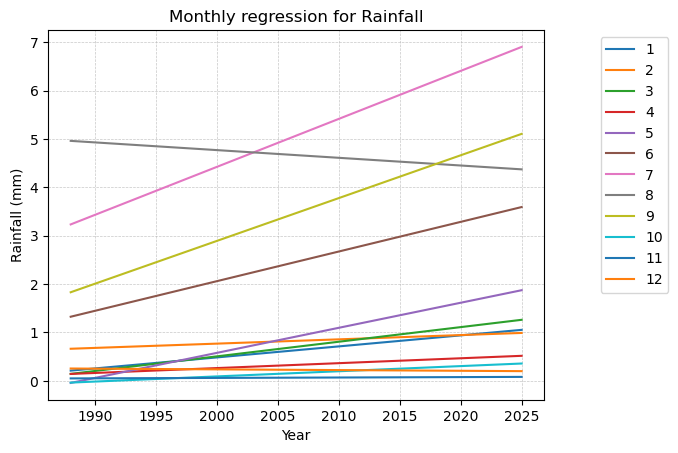

In [40]:
model = LinearRegression()
dff = df.dropna(subset=["RF"])
for i in range(12):
    temp=dff[dff["TIME"].dt.month==(i+1)]
    model.fit(temp["TIME"].dt.year.values.reshape(-1, 1), temp["RF"])
    y_pred = model.predict(temp["TIME"].dt.year.values.reshape(-1, 1))
    plt.plot(temp["TIME"].dt.year, y_pred, label=str(i+1))
plt.legend(loc='upper left', bbox_to_anchor=(1.1, 1))
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Monthly regression for Rainfall")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.017950516331925348), z=np.float64(2.366637266411687), Tau=np.float64(0.26884779516358465), s=np.float64(189.0), var_s=np.float64(6310.333333333333), slope=np.float64(10.5), intercept=np.float64(442.20000000000005))
MEAN:  596.5500000000002
SD:  363.62905270752634
CV:  60.9553352958723


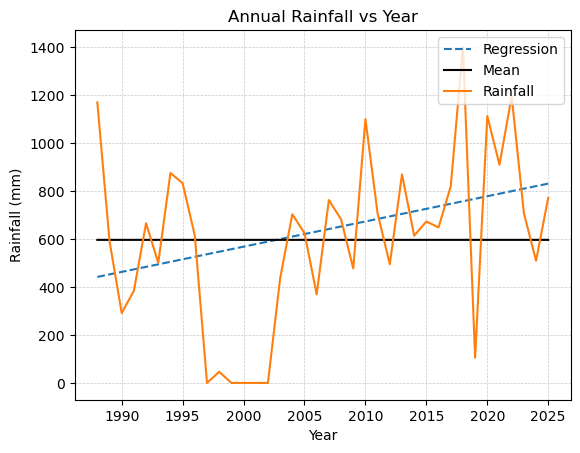

In [41]:
avg_rainfall=df.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Regression",linestyle="--")
plt.plot(df["TIME"].dt.year,np.ones(df["TIME"].dt.year.shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.plot(avg_rainfall["TIME"],avg_rainfall["RF"],label="Rainfall")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Annual Rainfall vs Year")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.1468185469334502), z=np.float64(1.4508610814819294), Tau=np.float64(0.16500711237553342), s=np.float64(116.0), var_s=np.float64(6282.666666666667), slope=np.float64(0.6606060606060606), intercept=np.float64(14.678787878787876))
MEAN:  42.94473684210526
SD:  49.56360749346958
CV:  115.4125304707301


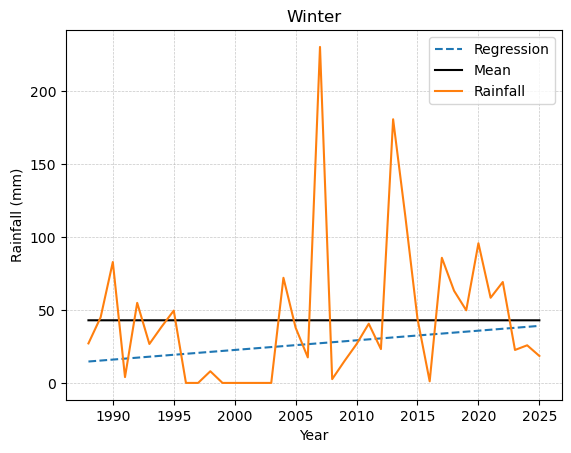

In [42]:
dff = winter
avg_rainfall=dff.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Regression",linestyle="--")
plt.plot(dff["TIME"].dt.year,np.ones(dff["TIME"].shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.plot(avg_rainfall["TIME"],avg_rainfall["RF"],label="Rainfall")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Winter")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.006252590098981603), z=np.float64(2.734232373502955), Tau=np.float64(0.310099573257468), s=np.float64(218.0), var_s=np.float64(6298.666666666667), slope=np.float64(1.9571428571428573), intercept=np.float64(5.792857142857137))
MEAN:  60.00526315789473
SD:  61.93840422142343
CV:  103.22161917437465


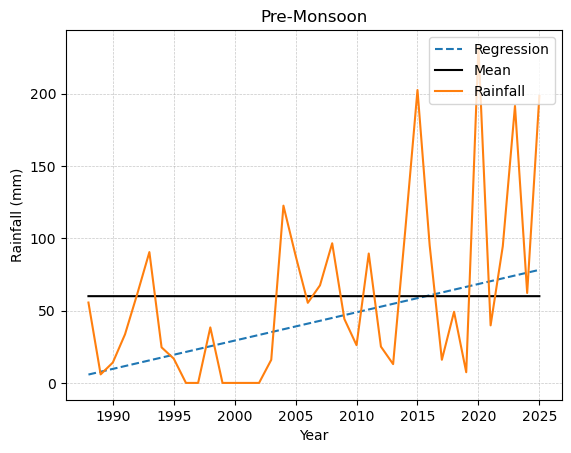

In [43]:
dff = premon
avg_rainfall=dff.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Regression",linestyle="--")
plt.plot(dff["TIME"].dt.year,np.ones(dff["TIME"].shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.plot(avg_rainfall["TIME"],avg_rainfall["RF"],label="Rainfall")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Pre-Monsoon")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.09377348639424499), z=np.float64(1.6758198418243917), Tau=np.float64(0.1906116642958748), s=np.float64(134.0), var_s=np.float64(6298.666666666667), slope=np.float64(6.791666666666667), intercept=np.float64(344.10416666666663))
MEAN:  479.628947368421
SD:  321.5635752431956
CV:  67.0442384696582


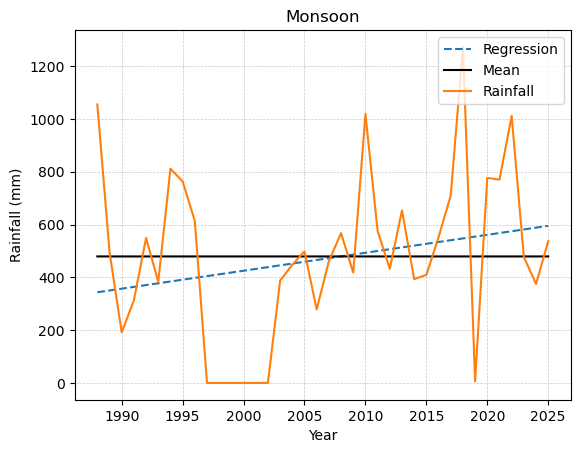

In [44]:
dff = mons
avg_rainfall=dff.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Regression",linestyle="--")
plt.plot(dff["TIME"].dt.year,np.ones(dff["TIME"].shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.plot(avg_rainfall["TIME"],avg_rainfall["RF"],label="Rainfall")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Monsoon")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.05265616415527341), z=np.float64(1.937730063033882), Tau=np.float64(0.2147937411095306), s=np.float64(151.0), var_s=np.float64(5992.333333333333), slope=np.float64(0.23636363636363633), intercept=np.float64(2.627272727272728))
MEAN:  13.971052631578948
SD:  16.616141743184173
CV:  118.93264009060059


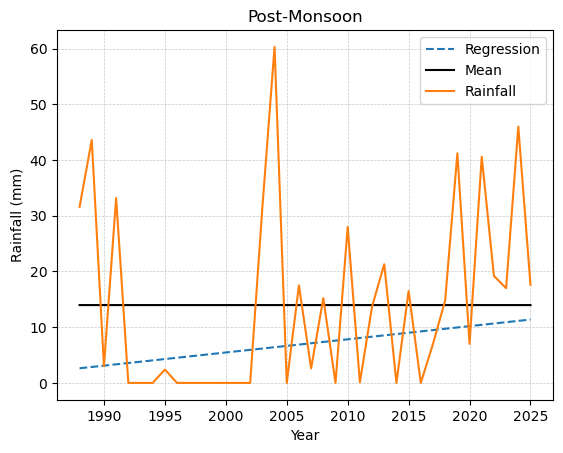

In [45]:
dff = postmon
avg_rainfall=dff.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Regression",linestyle="--")
plt.plot(dff["TIME"].dt.year,np.ones(dff["TIME"].shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.plot(avg_rainfall["TIME"],avg_rainfall["RF"],label="Rainfall")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Post-Monsoon")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.837011475105446), z=np.float64(-0.20571764439712248), Tau=np.float64(-0.06060606060606061), s=np.float64(-4.0), var_s=212.66666666666666, slope=np.float64(-37.034523809523805), intercept=np.float64(1061.0398809523808))
MEAN:  1889.075
SD:  2131.7274293292157
CV:  112.84503946795208


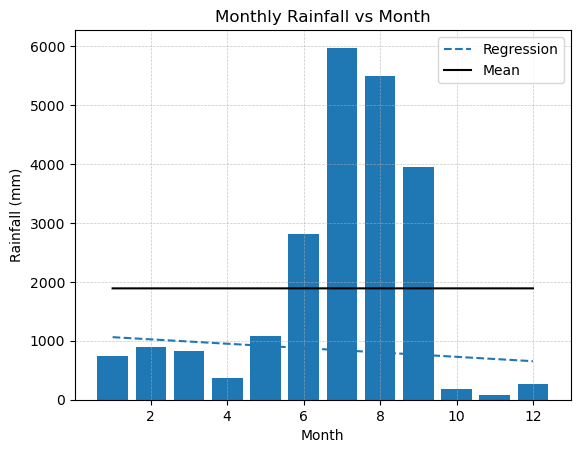

In [46]:
dff = df.dropna(subset=["RF"])
avg_rainfall=df.groupby(df["TIME"].dt.month)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Regression",linestyle="--")
plt.plot(df["TIME"].dt.month,np.ones(df["TIME"].dt.month.shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.bar(avg_rainfall["TIME"],avg_rainfall["RF"])
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.title("Monthly Rainfall vs Month")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

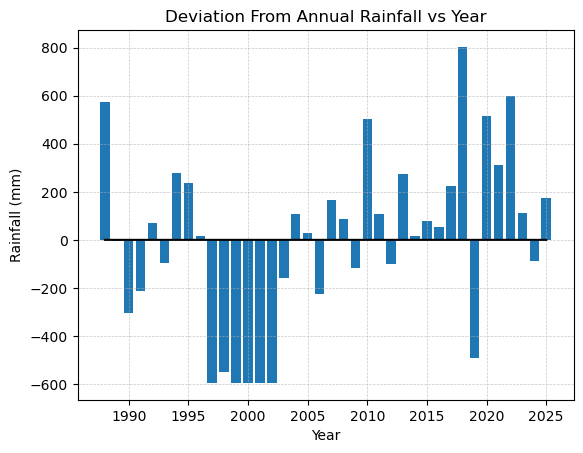

In [47]:
avg_rainfall=df.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
plt.plot(df["TIME"].dt.year,np.ones(df["TIME"].dt.year.shape[0])*0,c="black")
plt.bar(avg_rainfall["TIME"],avg_rainfall["RF"]-avg_rainfall["RF"].mean())
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Deviation From Annual Rainfall vs Year")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

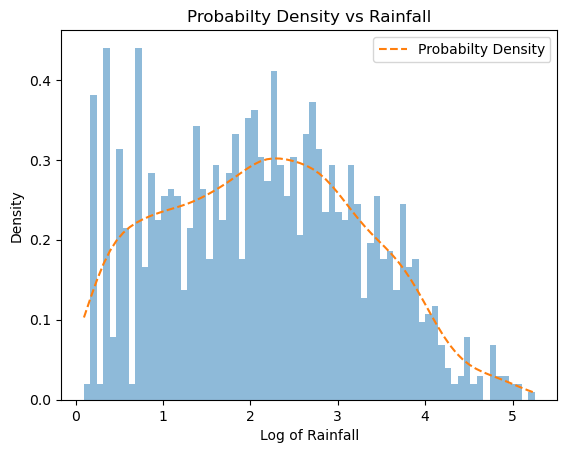

In [48]:
rf=np.array(df[df["RF"]>1]["RF"])
rf=np.log(rf)
plt.hist(rf,bins=70,density=True, alpha=0.5)
from scipy.stats import gaussian_kde
kde = gaussian_kde(rf)

x = np.linspace(rf.min(), rf.max(), 70)
plt.plot(x, kde(x),label="Probabilty Density",linestyle="--")
plt.xlabel("Log of Rainfall")
plt.ylabel("Density")
plt.title("Probabilty Density vs Rainfall")
plt.legend(loc="upper right")

In [49]:
print("Maximum Rainfall : ",dff["RF"].max())
print("Minimum Rainfall : ",dff["RF"].min())

Maximum Rainfall :  191.6
Minimum Rainfall :  0.0


<h1> Monsoon Trends</h1>

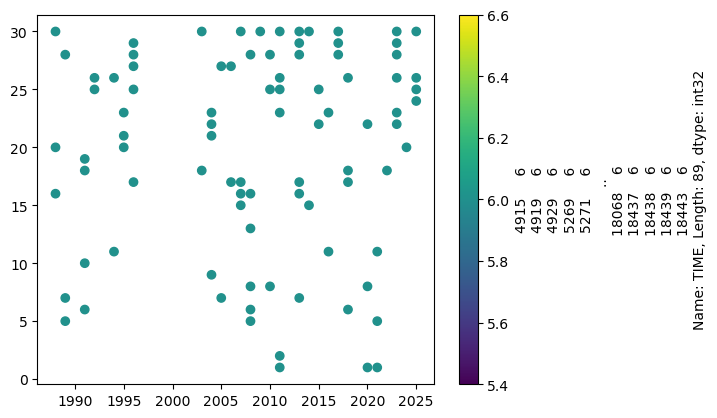

In [50]:
monss=mons[(mons["RF"]>=10)&(mons["TIME"].dt.month==6)]
plt.colorbar(plt.scatter(monss["TIME"].dt.year,monss["TIME"].dt.day,c=monss["TIME"].dt.month), label=monss["TIME"].dt.month)

In [51]:
rainfall_ls={}
for i in df_Years:
    try:
        rainfall_ls[int(i)]=np.where(np.diff(np.array(mons[mons["TIME"].dt.year==int(i)]["RF"]))>4)[0]
    except Exception as e:
        pass

In [52]:
ls={}
for i in rainfall_ls.keys():
    try:
        ls[i]=[rainfall_ls[i][0],rainfall_ls[i][-1],len(rainfall_ls[i])]
    except Exception as e:
        pass

Slope:  [-0.19007822]
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.7449214432744644), z=np.float64(-0.32534306195932644), Tau=np.float64(-0.04233870967741935), s=np.float64(-21.0), var_s=np.float64(3779.0), slope=np.float64(-0.03807471264367816), intercept=np.float64(11.090158045977011))


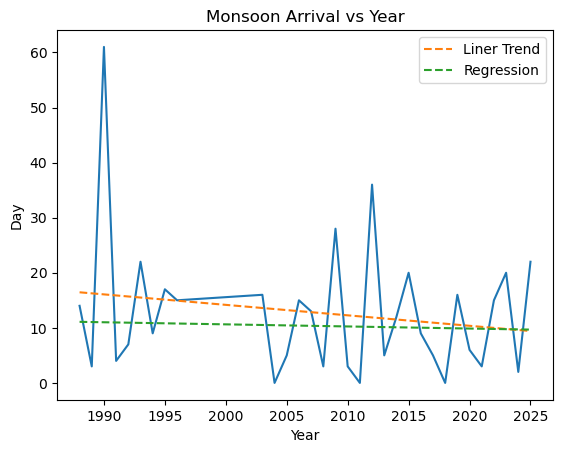

In [53]:
plt.plot(ls.keys(),np.array(list(ls.values()))[:,0])
model.fit(np.array(list(ls.keys())).reshape(-1,1),np.array(list(ls.values()))[:,0])
print("Slope: ",model.coef_)
plt.plot(np.array(list(ls.keys())).reshape(-1,1),model.predict(np.array(list(ls.keys())).reshape(-1,1)),label="Liner Trend",linestyle="--")
test=mk.original_test(np.array(list(ls.values()))[:,0])
print(test)
plt.plot(df_Years,test.slope*(df_Years-df_Years.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("Day")
plt.title("Monsoon Arrival vs Year")
plt.legend(loc="upper right")

Slope:  [-0.22169348]
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.7821602039759039), z=np.float64(0.27650502066875104), Tau=np.float64(0.036290322580645164), s=np.float64(18.0), var_s=np.float64(3780.0), slope=np.float64(0.025), intercept=np.float64(105.6125))


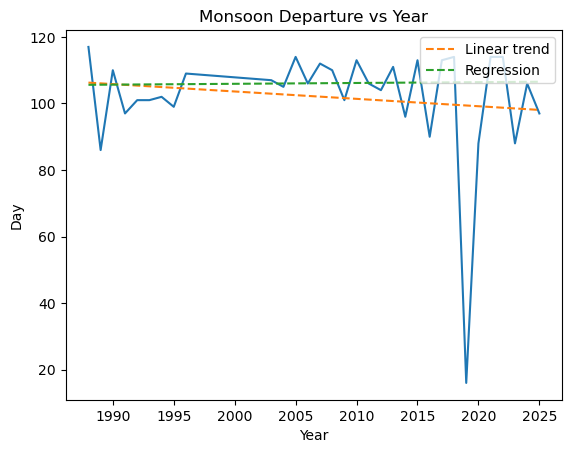

In [54]:
plt.plot(ls.keys(),np.array(list(ls.values()))[:,1])
model=LinearRegression()
model.fit(np.array(list(ls.keys())).reshape(-1,1),np.array(list(ls.values()))[:,1])
print("Slope: ",model.coef_)
plt.plot(np.array(list(ls.keys())).reshape(-1,1),model.predict(np.array(list(ls.keys())).reshape(-1,1)),label="Linear trend",linestyle="--")
test=mk.original_test(np.array(list(ls.values()))[:,1])
print(test)
plt.plot(df_Years,test.slope*(df_Years-df_Years.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("Day")
plt.title("Monsoon Departure vs Year")
plt.legend(loc="upper right")

Slope:  [-0.02166672]
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.948050688479553), z=np.float64(-0.06515487600178647), Tau=np.float64(-0.010080645161290322), s=np.float64(-5.0), var_s=np.float64(3769.0), slope=np.float64(0.0), intercept=np.float64(16.0))


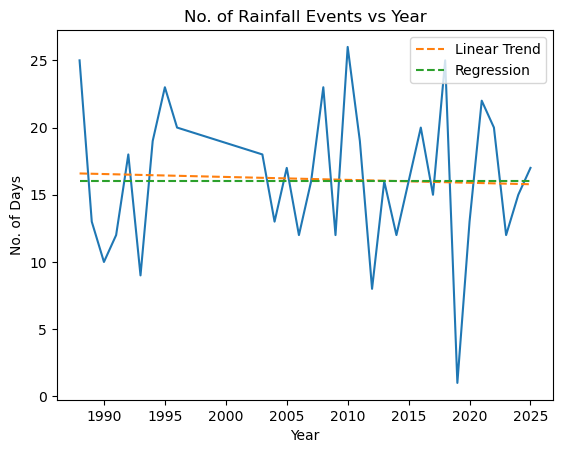

In [55]:
plt.plot(ls.keys(),np.array(list(ls.values()))[:,2])
model=LinearRegression()
model.fit(np.array(list(ls.keys())).reshape(-1,1),np.array(list(ls.values()))[:,2])
print("Slope: ",model.coef_)
plt.plot(np.array(list(ls.keys())).reshape(-1,1),model.predict(np.array(list(ls.keys())).reshape(-1,1)),label="Linear Trend",linestyle="--")
test=mk.original_test(np.array(list(ls.values()))[:,2])
print(test)
plt.plot(df_Years,test.slope*(df_Years-df_Years.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Days")
plt.title("No. of Rainfall Events vs Year")
plt.legend(loc="upper right")

Slope:  [-0.03161526]
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.6729047980021026), z=np.float64(0.4221647100914668), Tau=np.float64(0.05443548387096774), s=np.float64(27.0), var_s=np.float64(3793.0), slope=np.float64(0.14285714285714285), intercept=np.float64(90.78571428571429))


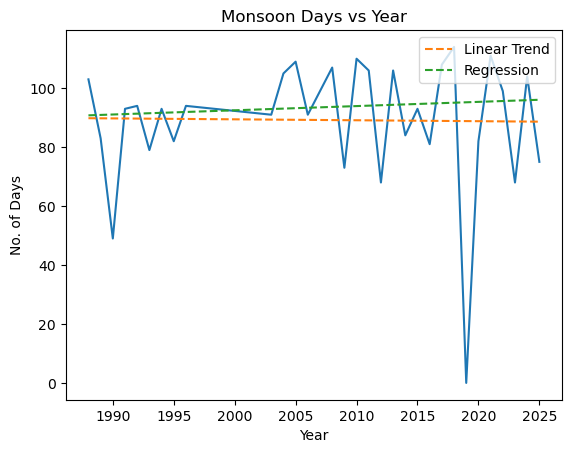

In [57]:
n_days=np.array(list(ls.values()))[:,1]-np.array(list(ls.values()))[:,0]
plt.plot(ls.keys(),n_days)
model=LinearRegression()
model.fit(np.array(list(ls.keys())).reshape(-1,1),n_days)
print("Slope: ",model.coef_)
plt.plot(np.array(list(ls.keys())).reshape(-1,1),model.predict(np.array(list(ls.keys())).reshape(-1,1)),label="Linear Trend",linestyle="--")
test=mk.original_test(n_days)
print(test)
plt.plot(df_Years,test.slope*(df_Years-df_Years.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Days")
plt.title("Monsoon Days vs Year")
plt.legend(loc="upper right")

<h1>Trends</h1>

In [ ]:
model=LinearRegression()
dff=df.dropna()
model.fit(dff["MIN"].values.reshape(-1, 1),dff["MAX"])
t=model.predict(dff["MIN"].values.reshape(-1, 1))
plt.plot(dff["MIN"],t)
plt.scatter(dff["MIN"],dff["MAX"],c=["yellow"])
plt.xlabel("Minimum Temp.")
plt.ylabel("Maximum Temp.")
plt.title("Relation b/w Max. and Min. Temperature")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

In [ ]:
from pandas.plotting import scatter_matrix

scatter_matrix(
    df[["MAX","MIN","RF"]],
    figsize=(8,8)

)

In [ ]:
dfExtMonthly.to_csv("extmonthyl.csv",index=False)